Python Project 3: An Exploration of Open Data


*   Analyze NYPD arrest data
*   Pick an initial comparison point and a feature with which to examine
* Compare the features of the identified comparator with another
* Include descriptive statistics, at least one cleaning task, and at least one visualization





In [1]:
#Import pandas, seaborn, matplotlib libraries
#Left-justify all visualizations

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
#Import NYPD dataset
#Review the first 5 rows

NYPDdata = pd.read_csv("https://data.cityofnewyork.us/resource/8h9b-rp9u.csv")

In [3]:
NYPDdata.head(5)

,arrest_key,arrest_date,pd_cd,pd_desc,ky_cd,ofns_desc,law_code,law_cat_cd,arrest_boro,arrest_precinct,jurisdiction_code,age_group,perp_sex,perp_race,x_coord_cd,y_coord_cd,latitude,longitude,lon_lat
0,318207869,2025-12-31T00:00:00.000,419,"LARCENY,GRAND FROM PERSON,UNCL",109,GRAND LARCENY,PL 1553005,F,M,14,0,45-64,M,WHITE HISPANIC,986944,214915,40.756568,-73.990276,POINT (-73.99027596 40.75656807)
1,318200244,2025-12-31T00:00:00.000,922,"TRAFFIC,UNCLASSIFIED MISDEMEAN",348,VEHICLE AND TRAFFIC LAWS,VTL0511001,M,Q,105,0,25-44,M,BLACK,1057888,198863,40.712203,-73.734379,POINT (-73.73437905 40.71220326)
2,318208155,2025-12-31T00:00:00.000,490,"STOLEN PROPERTY 3,POSSESSION",232,POSSESSION OF STOLEN PROPERTY,PL 1654000,M,B,47,0,18-24,M,BLACK,1033042,261993,40.885649,-73.823542,POINT (-73.82354248 40.88564938)
3,318190060,2025-12-31T00:00:00.000,639,AGGRAVATED HARASSMENT 2,361,OFF. AGNST PUB ORD SENSBLTY &,PL 2403002,M,Q,114,2,25-44,M,BLACK,999483,214809,40.756274,-73.945014,POINT (-73.945014 40.756274)
4,318178728,2025-12-31T00:00:00.000,203,"TRESPASS 3, CRIMINAL",352,CRIMINAL TRESPASS,PL 140100A,M,B,42,0,25-44,M,BLACK,1015085,241933,40.830682,-73.888577,POINT (-73.888577 40.830682)


In [4]:
NYPDdata.shape

(1000, 19)

In [5]:
NYPDdata.info()

#Identified the data types and that there are two null values in the law_cat_cd

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   arrest_key         1000 non-null   int64  
 1   arrest_date        1000 non-null   object 
 2   pd_cd              1000 non-null   int64  
 3   pd_desc            1000 non-null   object 
 4   ky_cd              1000 non-null   int64  
 5   ofns_desc          1000 non-null   object 
 6   law_code           1000 non-null   object 
 7   law_cat_cd         997 non-null    object 
 8   arrest_boro        1000 non-null   object 
 9   arrest_precinct    1000 non-null   int64  
 10  jurisdiction_code  1000 non-null   int64  
 11  age_group          1000 non-null   object 
 12  perp_sex           1000 non-null   object 
 13  perp_race          1000 non-null   object 
 14  x_coord_cd         1000 non-null   int64  
 15  y_coord_cd         1000 non-null   int64  
 16  latitude           1000 n

In [6]:
# Identify the two records with null values

NYPDdata[NYPDdata.isnull().any(axis=1)]

,arrest_key,arrest_date,pd_cd,pd_desc,ky_cd,ofns_desc,law_code,law_cat_cd,arrest_boro,arrest_precinct,jurisdiction_code,age_group,perp_sex,perp_race,x_coord_cd,y_coord_cd,latitude,longitude,lon_lat
546,318274940,2025-12-30T00:00:00.000,49,U.S. CODE UNCLASSIFIED,995,FOR OTHER AUTHORITIES,FOA9000049,NaN,M,5,0,45-64,M,BLACK HISPANIC,983858,199256,40.713598,-74.001413,POINT (-74.001413 40.713598)
753,318272594,2025-12-30T00:00:00.000,49,U.S. CODE UNCLASSIFIED,995,FOR OTHER AUTHORITIES,FOA9000049,NaN,M,5,0,25-44,M,WHITE HISPANIC,983858,199256,40.713598,-74.001413,POINT (-74.001413 40.713598)
893,318272588,2025-12-30T00:00:00.000,49,U.S. CODE UNCLASSIFIED,995,FOR OTHER AUTHORITIES,FOA9000049,NaN,M,5,0,25-44,M,WHITE HISPANIC,983858,199256,40.713598,-74.001413,POINT (-74.001413 40.713598)


In [7]:
# Remove the two null records
  # Confirm the records are removed if the total number of rows is 998

PD_clean = NYPDdata.dropna()
PD_clean.shape

(997, 19)

In [8]:
# Remove unnecerssary features

PD_final = PD_clean.drop(columns=["pd_cd","pd_desc","ky_cd","x_coord_cd","y_coord_cd"])
PD_final.tail(5)

,arrest_key,arrest_date,ofns_desc,law_code,law_cat_cd,arrest_boro,arrest_precinct,jurisdiction_code,age_group,perp_sex,perp_race,latitude,longitude,lon_lat
995,318162016,2025-12-30T00:00:00.000,VEHICLE AND TRAFFIC LAWS,VTL0511001,M,B,40,0,(null),(null),BLACK,40.814937,-73.914954,POINT (-73.91495387 40.8149368)
996,318136689,2025-12-30T00:00:00.000,ASSAULT 3 & RELATED OFFENSES,PL 121110H,F,S,120,0,25-44,M,WHITE HISPANIC,40.645005,-74.077265,POINT (-74.077265 40.645005)
997,318126085,2025-12-30T00:00:00.000,OTHER OFFENSES RELATED TO THEFT,PL 1651503,M,K,73,1,25-44,M,BLACK,40.678587,-73.906129,POINT (-73.90612894 40.67858725)
998,318144115,2025-12-30T00:00:00.000,PETIT LARCENY,PL 1552500,M,M,13,0,45-64,M,WHITE,40.737082,-73.982963,POINT (-73.982963 40.737082)
999,318148389,2025-12-30T00:00:00.000,OFF. AGNST PUB ORD SENSBLTY &,PL 2405001,M,B,46,0,25-44,F,WHITE HISPANIC,40.853586,-73.900592,POINT (-73.900592 40.853586)


Research Question 1: Which precinct has the most arrests overall?  What is the most common age/race/gender of the arrestees in this precinct?


Research Question 2: What is the most common age/race/gender of the arrestees in this precinct compared with the demographics of all arrestees?

In [9]:
PD_final["arrest_key"].is_unique

True

In [10]:
# The precinct with the most arrests is the 14th Precinct

PD_final.groupby(['arrest_precinct'])['arrest_key'].count().sort_values(ascending=False)

,arrest_key
arrest_precinct,
14,44
47,33
40,31
110,29
41,27
...,...
7,3
111,3
30,3


In [20]:
# Examine the demographics of arrestees in the 14th Precinct by
  # Age
  # Race
  # Gender

PD_14 = PD_final[PD_final["arrest_precinct"] == 14]
PD_14.groupby(["age_group"])["arrest_key"].count()

,arrest_key
age_group,
(null),9
18-24,4
25-44,20
45-64,10
<18,1


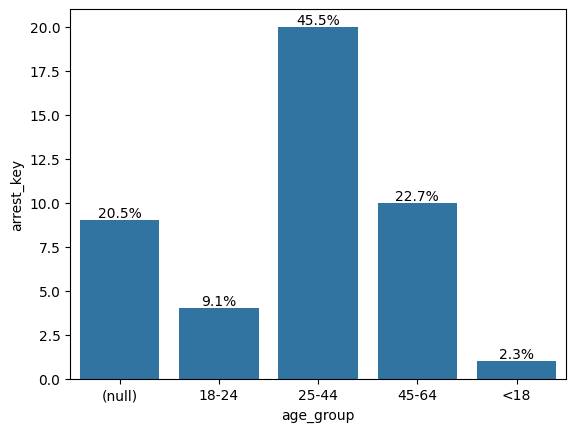

In [40]:
grouped_14age = PD_14.groupby("age_group")["arrest_key"].count().reset_index()
grouped_14age["percent"] = grouped_14age["arrest_key"] / grouped_14age["arrest_key"].sum() * 100

ax = sns.barplot(data=grouped_14age, x="age_group", y="arrest_key")

for i, row in grouped_14age.iterrows():
    ax.text(i, row["arrest_key"], f'{row["percent"]:.1f}%',
            ha='center', va='bottom')

plt.show()

In [21]:
PD_14.groupby(["perp_race"])["arrest_key"].count()

,arrest_key
perp_race,
ASIAN / PACIFIC ISLANDER,4
BLACK,17
BLACK HISPANIC,2
WHITE,7
WHITE HISPANIC,14


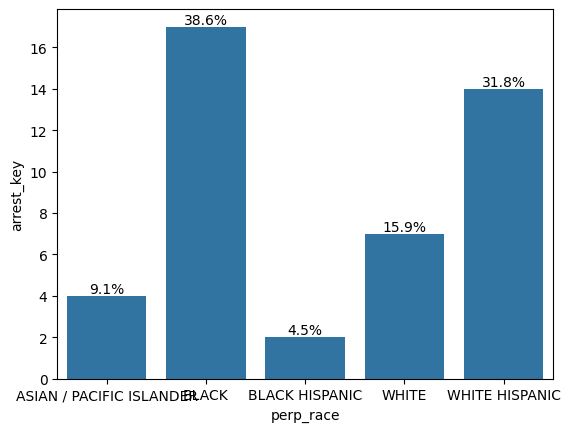

In [42]:
grouped_14race = PD_14.groupby("perp_race")["arrest_key"].count().reset_index()
grouped_14race["percent"] = grouped_14race["arrest_key"] / grouped_14race["arrest_key"].sum() * 100

ax = sns.barplot(data=grouped_14race, x="perp_race", y="arrest_key")

for i, row in grouped_14race.iterrows():
    ax.text(i, row["arrest_key"], f'{row["percent"]:.1f}%',
            ha='center', va='bottom')

plt.show()

In [22]:
PD_14.groupby(["perp_sex"])["arrest_key"].count()

,arrest_key
perp_sex,
(null),9
F,2
M,33


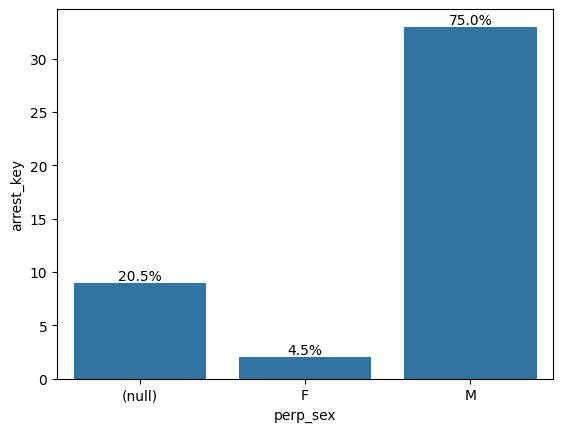

In [44]:
grouped_14sex = PD_14.groupby("perp_sex")["arrest_key"].count().reset_index()
grouped_14sex["percent"] = grouped_14sex["arrest_key"] / grouped_14sex["arrest_key"].sum() * 100

ax = sns.barplot(data=grouped_14sex, x="perp_sex", y="arrest_key")

for i, row in grouped_14sex.iterrows():
    ax.text(i, row["arrest_key"], f'{row["percent"]:.1f}%',
            ha='center', va='bottom')

plt.show()

In [59]:
top_14 = (PD_14.groupby(["age_group", "perp_race", "perp_sex"]).size().reset_index(name="count").sort_values("count", ascending=False).iloc[0])

print(top_14)

age_group    25-44
perp_race    BLACK
perp_sex         M
count            9
Name: 8, dtype: object


Research Question 1 Answer: The 14th Precinct had the most arrests in the given time period of the dataset. The most common arrested individual was a 25 - 44 year old Black male.

In [36]:
PD_final.groupby(["age_group"])["arrest_key"].count()

,arrest_key
age_group,
(null),201
18-24,126
25-44,464
45-64,154
65+,26
<18,26


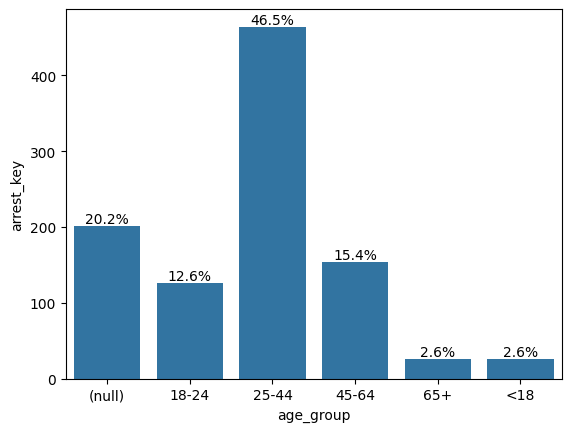

In [45]:
grouped_age = PD_final.groupby("age_group")["arrest_key"].count().reset_index()
grouped_age["percent"] = grouped_age["arrest_key"] / grouped_age["arrest_key"].sum() * 100

ax = sns.barplot(data=grouped_age, x="age_group", y="arrest_key")

for i, row in grouped_age.iterrows():
    ax.text(i, row["arrest_key"], f'{row["percent"]:.1f}%',
            ha='center', va='bottom')

plt.show()

In [37]:
PD_final.groupby(["perp_race"])["arrest_key"].count()

,arrest_key
perp_race,
AMERICAN INDIAN/ALASKAN NATIVE,2
ASIAN / PACIFIC ISLANDER,61
BLACK,523
BLACK HISPANIC,90
UNKNOWN,3
WHITE,84
WHITE HISPANIC,234


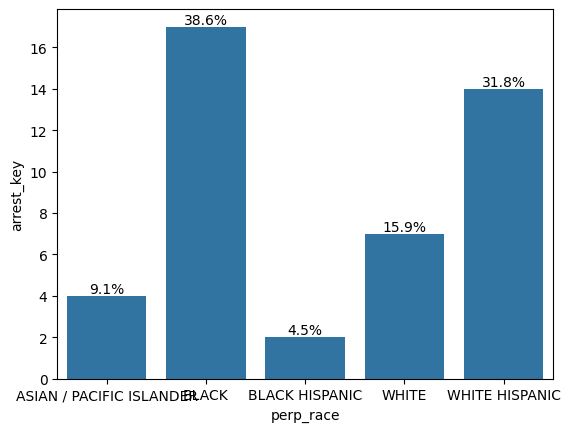

In [46]:
grouped_race = PD_14.groupby("perp_race")["arrest_key"].count().reset_index()
grouped_race["percent"] = grouped_race["arrest_key"] / grouped_race["arrest_key"].sum() * 100

ax = sns.barplot(data=grouped_race, x="perp_race", y="arrest_key")

for i, row in grouped_race.iterrows():
    ax.text(i, row["arrest_key"], f'{row["percent"]:.1f}%',
            ha='center', va='bottom')

plt.show()

In [38]:
PD_final.groupby(["perp_sex"])["arrest_key"].count()

,arrest_key
perp_sex,
(null),201
F,145
M,651


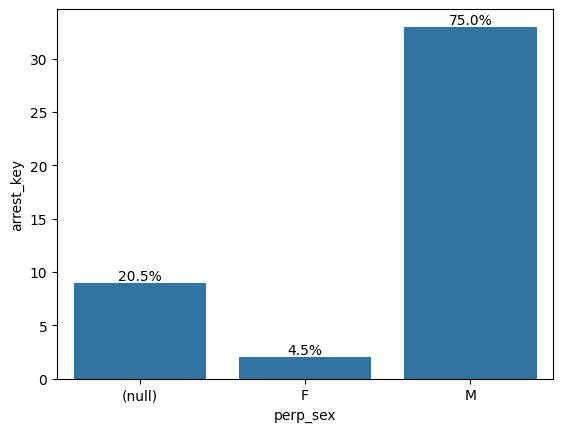

In [47]:
grouped_sex = PD_14.groupby("perp_sex")["arrest_key"].count().reset_index()
grouped_sex["percent"] = grouped_sex["arrest_key"] / grouped_sex["arrest_key"].sum() * 100

ax = sns.barplot(data=grouped_sex, x="perp_sex", y="arrest_key")

for i, row in grouped_sex.iterrows():
    ax.text(i, row["arrest_key"], f'{row["percent"]:.1f}%',
            ha='center', va='bottom')

plt.show()

In [57]:
top = (PD_final.groupby(["age_group", "perp_race", "perp_sex"]).size().reset_index(name="count").sort_values("count", ascending=False).iloc[0])

print(top)

age_group    25-44
perp_race    BLACK
perp_sex         M
count          186
Name: 18, dtype: object


Research Question 2 Answer: Of all the precincts, the most common arrested individual was a 25 - 44 year old Black male.

Conclusion: In both the 14th Precinct and of all precincts combined, the most common arrested individual was a 25 to 44 year-old Black man. Further considerations should include whether the demographics of arrested individuals are consistent with the demographics of the area.